In [1]:
from tqdm import tqdm
import torch.amp as amp
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from src.dataset import MRIDataset, load_subsets
from src.tumor_detector import TumorDetector, TumorLoss

In [ ]:
dataset_root = r"C:\Users\yuval\.cache\kagglehub\datasets\mateuszbuda\lgg-mri-segmentation\versions\2\kaggle_3m"
dataset = MRIDataset(dataset_root, limit=None)

# load the trand and val datasets
train_dataset, val_dataset, _ = load_subsets(dataset, train=True, val=True)

# create dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  pin_memory=True, num_workers=0)
val_loader = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = TumorDetector().to(device)
criterion = TumorLoss(dice_weight=0.6, bce_weight=0.4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3) # ready for tuning the lr so the DiceScore goes up

cuda


In [9]:
# Training
scaler = amp.GradScaler('cuda') # scales the loss for stability (prevents vanishing gradients)

num_epochs = 50
best_avg_dice = 0
graph_dice, graph_loss = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]") # setting dynamic progress bar

    # iterating batch-wise
    for images, gts in pbar:
        images, gts = images.to(device), gts.to(device)
        optimizer.zero_grad()


        with amp.autocast('cuda'): # enabling switching between fp16 and fp32 for speed
            logits = model(images) # feed forward
            loss = criterion(logits, gts)

        # scaled backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # calc metrics
        _dice_score = criterion.dice_score(logits, gts)
        train_loss += loss.item()

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "dice": f"{_dice_score:.4f}"}) # update progress bar

    # Validation
    model.eval()
    val_dice_score = 0
    with torch.no_grad():
        for images, gts in val_loader:
            images, gts = images.to(device), gts.to(device)

            with amp.autocast('cuda'): # enabling switching between fp16 and fp32 for speed
                logits = model(images) # feed forward

            # calc metrics
            _dice_score = criterion.dice_score(logits, gts)
            val_dice_score += _dice_score

    avg_dice = val_dice_score / len(val_loader)
    avg_loss = train_loss / len(train_loader)

    print(f"\nSummary Epoch [{epoch+1}/{num_epochs}] "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Avg Dice: {avg_dice:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # save best model so far
    if best_avg_dice <= avg_dice:
        best_avg_dice = avg_dice
        torch.save(model.state_dict(), "../brain_tumor_model_v6.pth")
        print(f"--- model saved with dice score: {best_avg_dice:.4f}")
    print("-" * 30)

    # reduce lr between epochs based on avg_dice
    scheduler.step(avg_dice)
    graph_dice.append(avg_dice)
    graph_loss.append(avg_loss)

Epoch 1/50 [Train]: 100%|██████████| 197/197 [01:53<00:00,  1.74it/s, loss=0.6545, dice=0.4535]



Summary Epoch [1/50] Avg Loss: 0.7051 | Avg Dice: 0.3665 | LR: 0.0001000
--- model saved with dice score: 0.3665
------------------------------


Epoch 2/50 [Train]: 100%|██████████| 197/197 [01:57<00:00,  1.68it/s, loss=0.6146, dice=0.4914]



Summary Epoch [2/50] Avg Loss: 0.6470 | Avg Dice: 0.5185 | LR: 0.0001000
--- model saved with dice score: 0.5185
------------------------------


Epoch 3/50 [Train]: 100%|██████████| 197/197 [01:53<00:00,  1.73it/s, loss=0.5914, dice=0.5171]


...


Summary Epoch [48/50] Avg Loss: 0.4294 | Avg Dice: 0.8447 | LR: 0.0000010
------------------------------


Epoch 49/50 [Train]: 100%|██████████| 197/197 [01:53<00:00,  1.74it/s, loss=0.4365, dice=0.9171]



Summary Epoch [49/50] Avg Loss: 0.4288 | Avg Dice: 0.8491 | LR: 0.0000001
------------------------------


Epoch 50/50 [Train]: 100%|██████████| 197/197 [01:52<00:00,  1.75it/s, loss=0.4437, dice=0.8590]



Summary Epoch [50/50] Avg Loss: 0.4288 | Avg Dice: 0.8475 | LR: 0.0000001
------------------------------


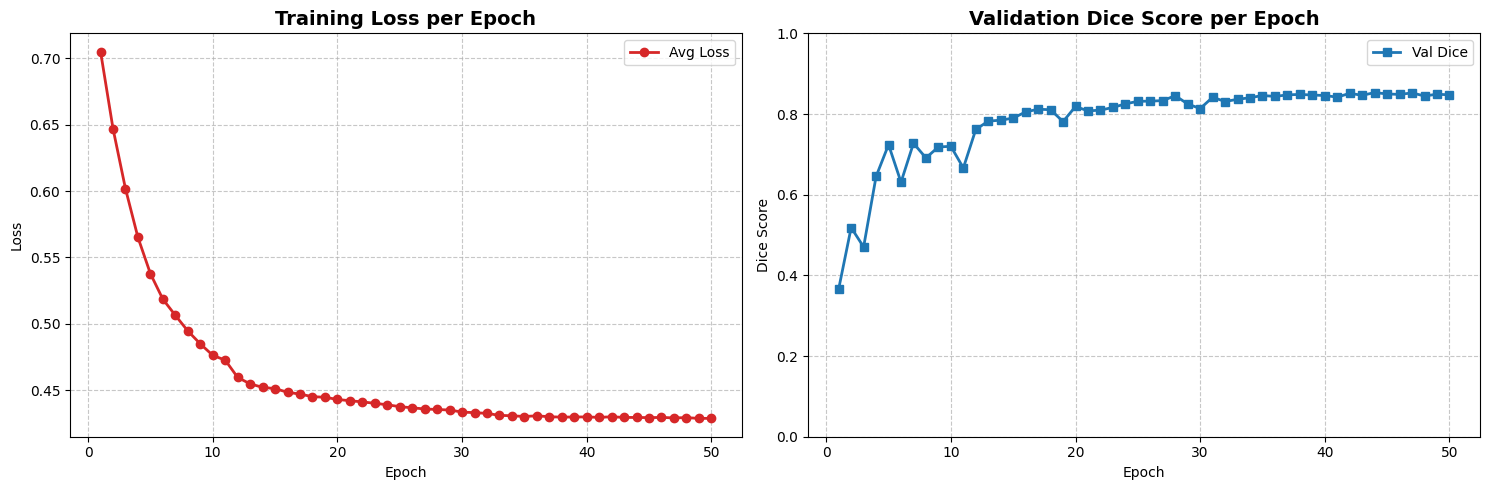

In [10]:
# Visualising Training
epochs = list(range(1, num_epochs+1))

# convert tensors to cpu and then to numpy/float
dice_coords = [d.cpu().item() if hasattr(d, 'cpu') else d for d in graph_dice]
loss_coords = [l.cpu().item() if hasattr(l, 'cpu') else l for l in graph_loss]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# plot 1: loss
ax1.plot(epochs, loss_coords, color='tab:red', marker='o', linestyle='-', linewidth=2, label='Avg Loss')
ax1.set_title('Training Loss per Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# plot 2: dice
ax2.plot(epochs, dice_coords, color='tab:blue', marker='s', linestyle='-', linewidth=2, label='Val Dice')
ax2.set_title('Validation Dice Score per Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_ylim(0, 1.0)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()